# Project: Cats vs Dogs Classification with PyTorch

Goal:
- load and inspect the Cats vs Dogs dataset
- create train / validation / test loaders
- visualize sample images
- define a first baseline CNN
- verify one forward pass

## Data

We are using the `Cats and Dogs Classification Dataset` from Kaggle.

The dataset contains 24,998 images, split into 12,499 Cat images and 12,499 Dog images. The training images are divided equally between cat and dog images.

Before starting, we checked for corrupted files with `check_corrupted.py` and removed them.

In [1]:
# Imports and device configuration
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Handle truncated images gracefully
import warnings
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", message=".*Truncated File Read.*")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [2]:
# Define simple data transformations
image_size = 128

transform = transforms.Compose([transforms.Resize((image_size, image_size)), transforms.ToTensor()])

In [3]:
# Load the full dataset
data_dir = Path("../PetImages")

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class to idx:", full_dataset.class_to_idx)

Total images: 24998
Classes: ['Cat', 'Dog']
Class to idx: {'Cat': 0, 'Dog': 1}


## Train / val / test split

We will be splitting as below:
- 80% train,
- 10% val,
- 10% test,

and proceed with minibatch training with a batch size of 32.

In [4]:
# Train/val/test split
dataset_size = len(full_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42) # for reproducable results

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 19998
Val size: 2499
Test size: 2501


In [5]:
# Create dataloaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Sample inspection

In [6]:
# Check a single sample
image, label = full_dataset[0]

print("Single image shape:", image.shape)
print("Label:", label)
print("Class name:", full_dataset.classes[label])

Single image shape: torch.Size([3, 128, 128])
Label: 0
Class name: Cat


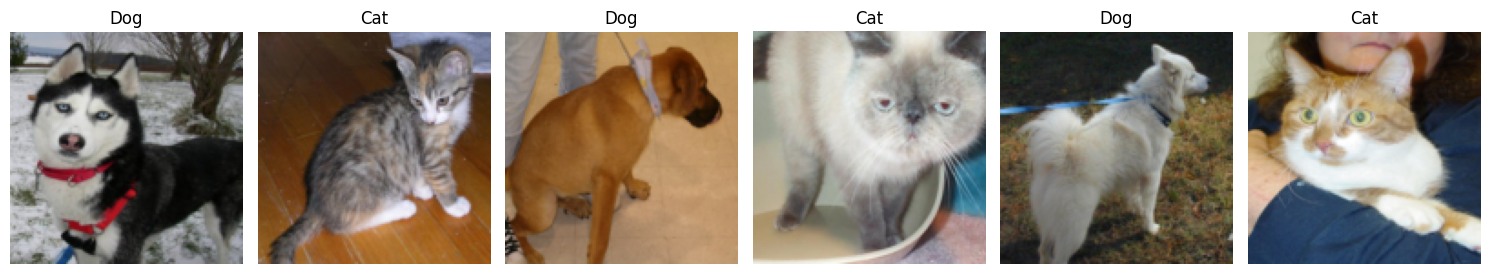

In [7]:
# Visualize some samples
fig, axes = plt.subplots(1, 6, figsize=(15, 4))

for i in range(6):
    # image, label = full_dataset[i]
    image, label = train_dataset[i] # using train dataset to visualize samples
    image_np = image.permute(1, 2, 0).numpy()

    axes[i].imshow(image_np)
    axes[i].set_title(full_dataset.classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("../figures/sample_images.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Check a batch of data
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("First 10 labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])
First 10 labels: tensor([0, 0, 1, 0, 0, 1, 1, 0, 1, 0])


In [9]:
# Check class balance in each split: we want to make sure we have a good mix of cats and dogs in each split, otherwise our model might not learn properly
def count_labels(subset):
    counts = Counter()
    for _, label in subset:
        counts[label] += 1
    return counts

train_counts = count_labels(train_dataset)
val_counts = count_labels(val_dataset)
test_counts = count_labels(test_dataset)

idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

for split_name, counts in [("train", train_counts), ("val", val_counts), ("test", test_counts)]:
    print(split_name)
    for idx, count in counts.items():
        print(f"  {idx_to_class[idx]}: {count}")

train
  Dog: 10003
  Cat: 9995
val
  Cat: 1244
  Dog: 1255
test
  Dog: 1241
  Cat: 1260


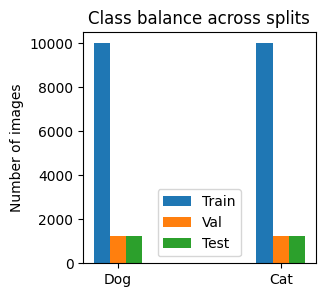

In [10]:
labels = [idx_to_class[i] for i in train_counts.keys()]

train_vals = [train_counts[i] for i in train_counts.keys()]
val_vals = [val_counts[i] for i in val_counts.keys()]
test_vals = [test_counts[i] for i in test_counts.keys()]

x = np.arange(len(labels))
width = 0.1

plt.figure(figsize=(3,3))

plt.bar(x - width, train_vals, width, label='Train')
plt.bar(x, val_vals, width, label='Val')
plt.bar(x + width, test_vals, width, label='Test')

plt.xticks(x, labels)
plt.ylabel("Number of images")
plt.title("Class balance across splits")
plt.legend(loc='best')
plt.savefig("../figures/class_balance.png", dpi=300, bbox_inches='tight')
plt.show()

Rougly balanced cats and dogs: OK!

## Define simple CNN

In [11]:
# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 128 -> 64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64 -> 32
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
# Instantiate the model and move it to the device
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


## One forward pass

In [13]:
# Check the model output shape
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print(outputs[:2])

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 2])
tensor([[-0.0553,  0.0023],
        [-0.0539,  0.0116]], device='mps:0', grad_fn=<SliceBackward0>)


## Feature maps

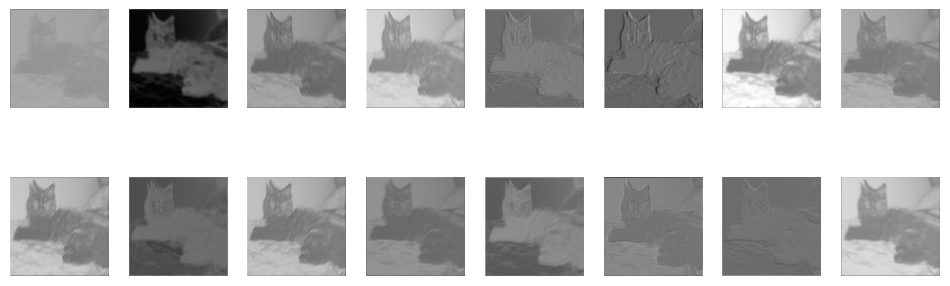

In [14]:
# Visualize the feature maps after the first convolutional layer
x = images[:1].to(device)

with torch.no_grad():
    feat = model.features[0](x)  # after first conv

feat = feat.cpu()[0]

fig, axes = plt.subplots(2, 8, figsize=(12,4))

for i, ax in enumerate(axes.flat):
    # ax.imshow(feat[i], cmap="gray")
    ax.imshow(feat[i], cmap="gray", vmin=feat.min(), vmax=feat.max()) # normalize each feature map to [0, 1] for better visualization
    ax.axis("off")
plt.savefig("../figures/feature_maps.png", dpi=300, bbox_inches='tight')
plt.show()

## Train the baseline CNN

Goal:
- train the baseline CNN on Cats vs Dogs
- monitor train and validation metrics
- visualize learning curves
- diagnose early signs of overfitting or underfitting

In [15]:
def training_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):

        # -----------------
        # Training
        # -----------------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = correct / total

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # -----------------
        # Validation
        # -----------------
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_acc = val_correct / val_total

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"train loss: {epoch_train_loss:.4f}, train acc: {epoch_train_acc:.4f} | "
            f"val loss: {epoch_val_loss:.4f}, val acc: {epoch_val_acc:.4f}"
        )
    return train_losses, train_accuracies, val_losses, val_accuracies

In [16]:
# Re-instantiate the model to reset weights before training
model = SimpleCNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train the baseline CNN
num_epochs = 10
train_losses, train_accuracies, val_losses, val_accuracies = training_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/10 | train loss: 0.6112, train acc: 0.6640 | val loss: 0.5579, val acc: 0.7159
Epoch 2/10 | train loss: 0.5012, train acc: 0.7563 | val loss: 0.5141, val acc: 0.7571
Epoch 3/10 | train loss: 0.4233, train acc: 0.8039 | val loss: 0.4733, val acc: 0.7775
Epoch 4/10 | train loss: 0.3350, train acc: 0.8533 | val loss: 0.5012, val acc: 0.7711
Epoch 5/10 | train loss: 0.2217, train acc: 0.9088 | val loss: 0.5984, val acc: 0.7759
Epoch 6/10 | train loss: 0.1116, train acc: 0.9601 | val loss: 0.7515, val acc: 0.7739
Epoch 7/10 | train loss: 0.0539, train acc: 0.9838 | val loss: 0.8419, val acc: 0.7679
Epoch 8/10 | train loss: 0.0290, train acc: 0.9920 | val loss: 1.1075, val acc: 0.7747
Epoch 9/10 | train loss: 0.0338, train acc: 0.9897 | val loss: 1.0239, val acc: 0.7639
Epoch 10/10 | train loss: 0.0194, train acc: 0.9943 | val loss: 1.2525, val acc: 0.7755


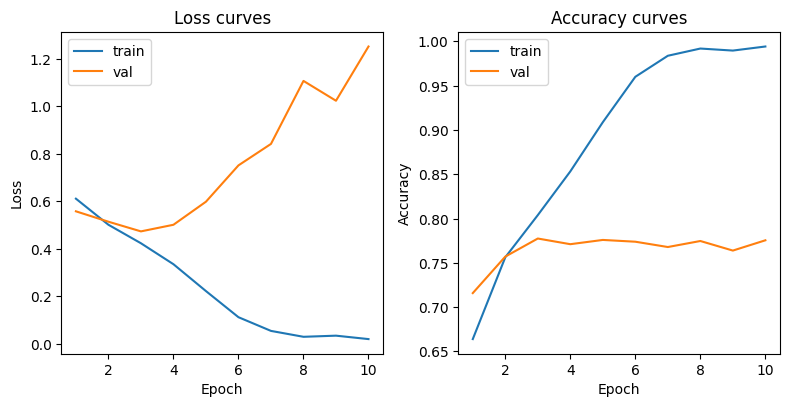

In [17]:
# Plot training and validation curves
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Loss
axes[0].plot(epochs, train_losses, label="train")
axes[0].plot(epochs, val_losses, label="val")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_aspect((axes[0].get_xlim()[1] - axes[0].get_xlim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0]))
axes[0].legend()

# Accuracy
axes[1].plot(epochs, train_accuracies, label="train")
axes[1].plot(epochs, val_accuracies, label="val")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_aspect((axes[1].get_xlim()[1] - axes[1].get_xlim()[0]) / (axes[1].get_ylim()[1] - axes[1].get_ylim()[0])) 
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/baseline_curves.png", dpi=300, bbox_inches='tight')
plt.show()

The baseline CNN learns the training set effectively, but begins to overfit after a few epochs:
- training loss decreases steadily
- training accuracy increases steadily
- validation loss decreases only at first, then rises
- validation accuracy peaks early and then stagnates

This indicates that the model has enough capacity to fit the training data, but does not yet generalize well to unseen images.

## Add data augmentation

In [18]:
# Define data augmentations for training and simple transforms for validation/test
image_size = 128

# For training, we apply random resized cropping and horizontal flipping to increase the diversity of our training data, which can help improve generalization.
train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

# For validation and test sets, we simply resize the images to a fixed size without any augmentations to evaluate the model's performance on consistent data.
val_test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

In [19]:
# Load the full dataset again with different transforms for train and eval
full_dataset_train = datasets.ImageFolder(data_dir, transform=train_transform_aug)
full_dataset_eval = datasets.ImageFolder(data_dir, transform=val_test_transform)

# Train/val/test split
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(full_dataset_train), generator=generator).tolist()

train_size = int(0.8 * len(indices))
val_size = int(0.1 * len(indices))
test_size = len(indices) - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

from torch.utils.data import Subset

train_dataset = Subset(full_dataset_train, train_indices)
val_dataset = Subset(full_dataset_eval, val_indices)
test_dataset = Subset(full_dataset_eval, test_indices)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 19998
Val size: 2499
Test size: 2501


In [20]:
# Recreate dataloaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

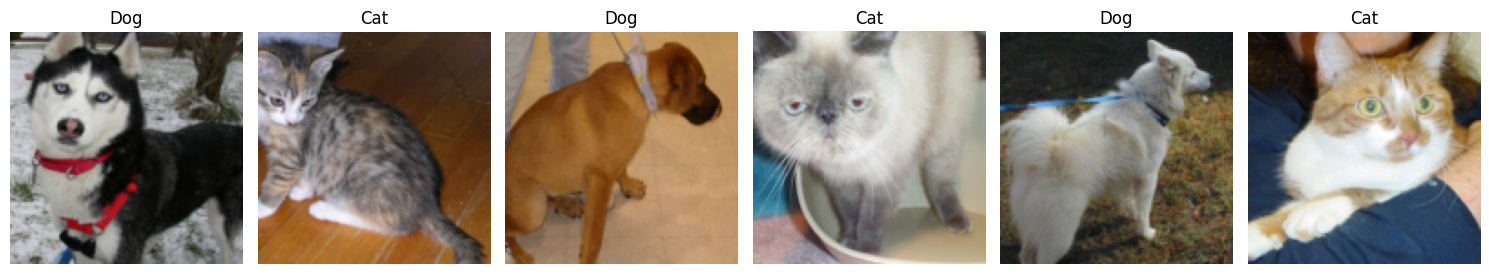

In [21]:
fig, axes = plt.subplots(1, 6, figsize=(15, 4))
for i in range(6):
    image, label = train_dataset[i]
    image_np = image.permute(1, 2, 0).numpy()
    axes[i].imshow(image_np)
    axes[i].set_title(full_dataset_train.classes[label])
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("../figures/sample_images_aug.png", dpi=300, bbox_inches='tight')
plt.show()

## Add regularization

In [22]:
# CNN with dropout for regularization
class SimpleCNNReg(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [23]:
# Experiment 1: data augmentation only (no dropout, no weight decay)
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_losses_aug, train_accs_aug, val_losses_aug, val_accs_aug = training_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/10 | train loss: 0.6459, train acc: 0.6189 | val loss: 0.6138, val acc: 0.6619
Epoch 2/10 | train loss: 0.5516, train acc: 0.7196 | val loss: 0.5274, val acc: 0.7339
Epoch 3/10 | train loss: 0.5046, train acc: 0.7484 | val loss: 0.5233, val acc: 0.7319
Epoch 4/10 | train loss: 0.4797, train acc: 0.7702 | val loss: 0.4923, val acc: 0.7591
Epoch 5/10 | train loss: 0.4517, train acc: 0.7859 | val loss: 0.4805, val acc: 0.7671
Epoch 6/10 | train loss: 0.4355, train acc: 0.7962 | val loss: 0.4693, val acc: 0.7747
Epoch 7/10 | train loss: 0.4198, train acc: 0.8051 | val loss: 0.4467, val acc: 0.7843
Epoch 8/10 | train loss: 0.4092, train acc: 0.8077 | val loss: 0.4550, val acc: 0.7871
Epoch 9/10 | train loss: 0.3944, train acc: 0.8216 | val loss: 0.4623, val acc: 0.7751
Epoch 10/10 | train loss: 0.3880, train acc: 0.8228 | val loss: 0.4398, val acc: 0.7959


In [24]:
# Experiment 2: data augmentation + dropout +weight decay
model_reg = SimpleCNNReg().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3, weight_decay=1e-4) # weight decay for regularization
train_losses_reg, train_accs_reg, val_losses_reg, val_accs_reg = training_loop(model_reg, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/10 | train loss: 0.6552, train acc: 0.6084 | val loss: 0.5843, val acc: 0.6887
Epoch 2/10 | train loss: 0.5769, train acc: 0.7013 | val loss: 0.5363, val acc: 0.7419
Epoch 3/10 | train loss: 0.5289, train acc: 0.7361 | val loss: 0.5145, val acc: 0.7403
Epoch 4/10 | train loss: 0.5042, train acc: 0.7544 | val loss: 0.4903, val acc: 0.7591
Epoch 5/10 | train loss: 0.4773, train acc: 0.7736 | val loss: 0.4795, val acc: 0.7683
Epoch 6/10 | train loss: 0.4603, train acc: 0.7854 | val loss: 0.4734, val acc: 0.7679
Epoch 7/10 | train loss: 0.4475, train acc: 0.7936 | val loss: 0.4469, val acc: 0.7883
Epoch 8/10 | train loss: 0.4436, train acc: 0.7968 | val loss: 0.4616, val acc: 0.7811
Epoch 9/10 | train loss: 0.4267, train acc: 0.8046 | val loss: 0.4293, val acc: 0.7995
Epoch 10/10 | train loss: 0.4152, train acc: 0.8111 | val loss: 0.4291, val acc: 0.8015


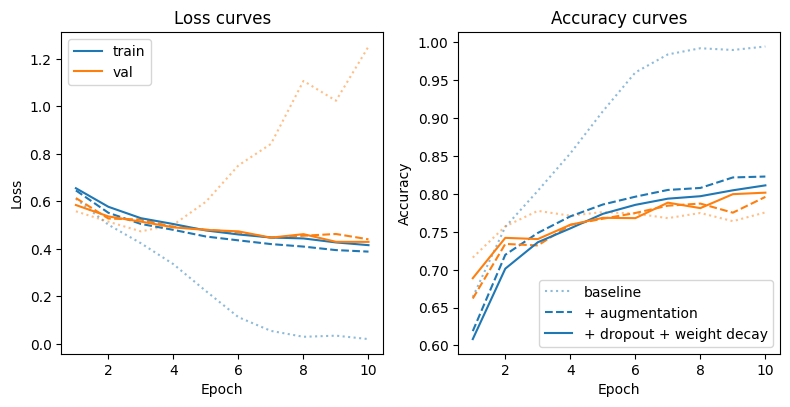

In [25]:
# Plot training and validation curves
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Loss : baseline
axes[0].plot(epochs, train_losses, color='tab:blue', linestyle='dotted', alpha=0.5)
axes[0].plot(epochs, val_losses, color='tab:orange', linestyle='dotted', alpha=0.5)
# data augmentation only
axes[0].plot(epochs, train_losses_aug, color='tab:blue', linestyle='dashed')
axes[0].plot(epochs, val_losses_aug, color='tab:orange', linestyle='dashed')
# data augmentation + dropout + weight decay
axes[0].plot(epochs, train_losses_reg, label="train", color='tab:blue', linestyle='solid')
axes[0].plot(epochs, val_losses_reg, label="val", color='tab:orange', linestyle='solid')

axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_aspect((axes[0].get_xlim()[1] - axes[0].get_xlim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0]))
axes[0].legend()

# Accuracy: baseline
axes[1].plot(epochs, train_accuracies, label="baseline", color='tab:blue', linestyle='dotted', alpha=0.5)
axes[1].plot(epochs, val_accuracies, color='tab:orange', linestyle='dotted', alpha=0.5)
# data augmentation only
axes[1].plot(epochs, train_accs_aug, label="+ augmentation", color='tab:blue', linestyle='dashed')
axes[1].plot(epochs, val_accs_aug, color='tab:orange', linestyle='dashed')
# data augmentation + dropout + weight decay
axes[1].plot(epochs, train_accs_reg, label="+ dropout + weight decay", color='tab:blue', linestyle='solid')
axes[1].plot(epochs, val_accs_reg, color='tab:orange', linestyle='solid')

axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_aspect((axes[1].get_xlim()[1] - axes[1].get_xlim()[0]) / (axes[1].get_ylim()[1] - axes[1].get_ylim()[0])) 
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/augmentation_regularization_curves.png", dpi=300, bbox_inches='tight')
plt.show()

Data augmentation significantly improved generalization and provided the largest performance gain.

Adding regularization (dropout + weight decay) reduced overfitting by narrowing the gap between training and validation metrics.

However, its impact on validation accuracy was small and inconsistent across runs, suggesting that the model was not heavily overfitting once augmentation was applied.

Overall, augmentation was the most important improvement, while additional regularization had a limited effect in this setup.

## Model selection

Among the custom CNN experiments, the augmentation-only model achieved the best validation performance.

Therefore, this model is selected as the final custom CNN baseline for test evaluation.

In [28]:
# Final evaluation on the test set using the best model (chosen based on validation performance)
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_images = []
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_images.append(images.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

test_loss /= len(test_loader)
test_acc = test_correct / test_total

all_images = torch.cat(all_images)
all_probs = torch.cat(all_probs)
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.4379
Test accuracy: 0.7957


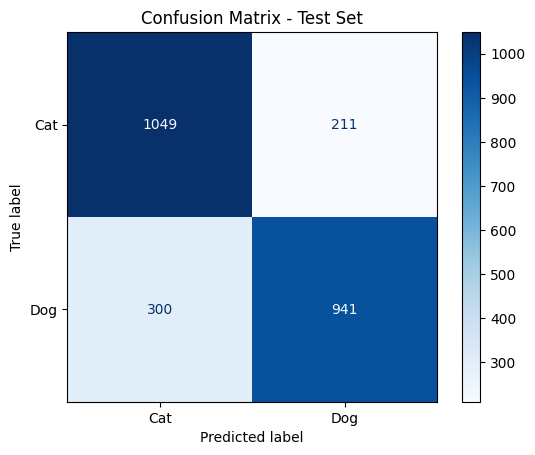

In [29]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset_eval.classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.savefig("../figures/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=full_dataset_eval.classes
))

              precision    recall  f1-score   support

         Cat       0.78      0.83      0.80      1260
         Dog       0.82      0.76      0.79      1241

    accuracy                           0.80      2501
   macro avg       0.80      0.80      0.80      2501
weighted avg       0.80      0.80      0.80      2501



In [31]:
# Analyze correct vs incorrect predictions
correct_indices = (all_preds == all_labels).nonzero(as_tuple=True)[0]
incorrect_indices = (all_preds != all_labels).nonzero(as_tuple=True)[0]

print("Correct examples:", len(correct_indices))
print("Incorrect examples:", len(incorrect_indices))

Correct examples: 1990
Incorrect examples: 511


In [32]:
# Visualize some correct and incorrect predictions
def show_examples(indices, title, n=6):
    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    fig.suptitle(title)

    for ax, idx in zip(axes, indices[:n]):
        image = all_images[idx].permute(1, 2, 0).numpy()
        true_label = full_dataset_eval.classes[all_labels[idx].item()]
        pred_label = full_dataset_eval.classes[all_preds[idx].item()]
        confidence = all_probs[idx].max().item()

        ax.imshow(image)
        ax.set_title(f"T: {true_label}\nP: {pred_label}\n{confidence:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

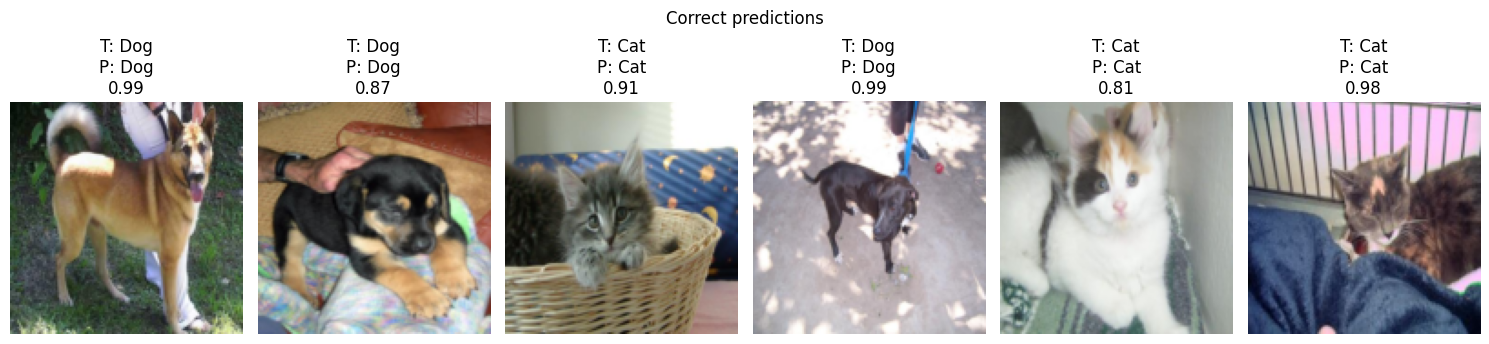

<Figure size 640x480 with 0 Axes>

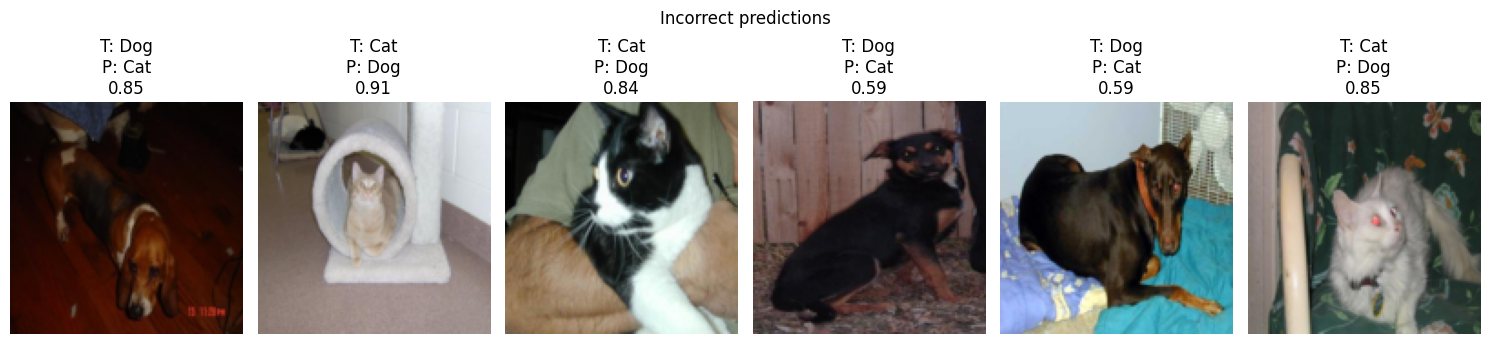

<Figure size 640x480 with 0 Axes>

In [33]:
show_examples(correct_indices, "Correct predictions") # correct predictions
plt.savefig("../figures/correct_predictions.png", dpi=300, bbox_inches='tight')
show_examples(incorrect_indices, "Incorrect predictions") # incorrect predictions
plt.savefig("../figures/incorrect_predictions.png", dpi=300, bbox_inches='tight')

In [34]:
# Visualize predicted probabilities for some examples
def show_prob_examples(indices, n=4):
    fig, axes = plt.subplots(n, 2, figsize=(8, 4*n))

    class_names = full_dataset_eval.classes

    for row, idx in enumerate(indices[:n]):
        image = all_images[idx].permute(1, 2, 0).numpy()
        probs = all_probs[idx].numpy()

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(
            f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].bar(class_names, probs)
        axes[row, 1].set_ylim(0, 1)
        axes[row, 1].set_title("Predicted probabilities")

    plt.tight_layout()
    plt.show()

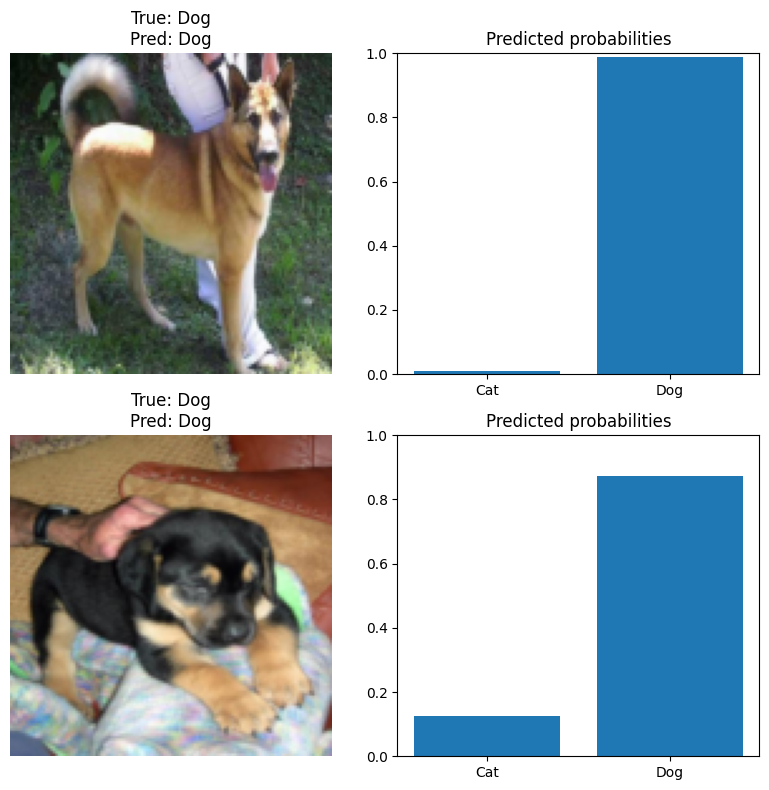

<Figure size 640x480 with 0 Axes>

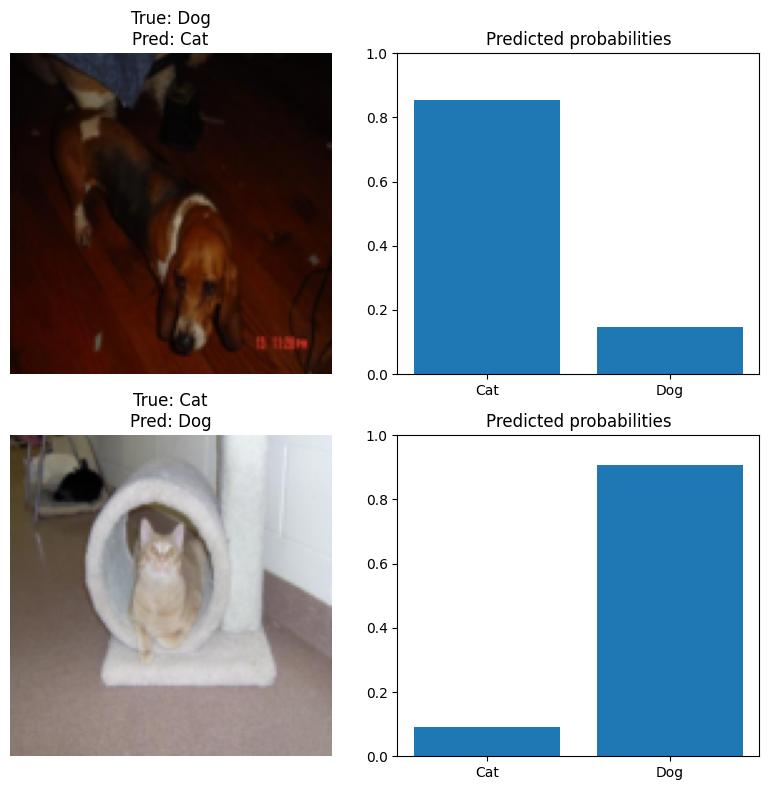

<Figure size 640x480 with 0 Axes>

In [35]:
show_prob_examples(correct_indices, n=2) # correct predictions
plt.savefig("../figures/correct_prediction_probs.png", dpi=300, bbox_inches='tight')
show_prob_examples(incorrect_indices, n=2) # incorrect predictions
plt.savefig("../figures/incorrect_prediction_probs.png", dpi=300, bbox_inches='tight')

In [36]:
# Save the best model checkpoint along with class names and image size for future inference
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": full_dataset_eval.classes,
    "image_size": image_size,
}, "best_custom_cnn_cats_dogs.pth")

## Final conclusions

This project explored image classification for cats vs dogs using MLP and CNN models.

Main findings:

- The MLP underperformed due to its inability to capture spatial structure in images.
- The baseline CNN significantly improved performance but suffered from overfitting.
- Data augmentation provided the most effective improvement, reducing overfitting and improving validation performance.
- Additional regularization (dropout and weight decay) had only limited impact beyond augmentation.

The final CNN model achieved a test accuracy of approximately 80%, with balanced precision and recall across both classes.

Error analysis showed that the model struggles with:
- low-light images
- unusual poses
- occlusions and cluttered backgrounds

Overall, the model learned meaningful visual features but remains sensitive to difficult or ambiguous inputs.

This project demonstrates the importance of CNN architectures and data augmentation in practical computer vision tasks.

## Transfer Learning with ResNet18

Goal:
- use a pretrained CNN as a fixed feature extractor
- train only the final classifier head
- compare its performance with the custom CNN

In [37]:
# ResNet18 expects 224x224 images and ImageNet normalization, so we need to adjust our transforms accordingly
image_size = 224

train_transform_tl = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform_tl = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
# Rebuild the datasets with the new transforms for transfer learning using the same split indices to ensure consistency
full_dataset_train_tl = datasets.ImageFolder(data_dir, transform=train_transform_tl)
full_dataset_eval_tl = datasets.ImageFolder(data_dir, transform=val_test_transform_tl)

train_dataset_tl = Subset(full_dataset_train_tl, train_indices)
val_dataset_tl = Subset(full_dataset_eval_tl, val_indices)
test_dataset_tl = Subset(full_dataset_eval_tl, test_indices)

In [39]:
# Create dataloaders for transfer learning
batch_size = 32

train_loader_tl = DataLoader(train_dataset_tl, batch_size=batch_size, shuffle=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=batch_size, shuffle=False)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=batch_size, shuffle=False)

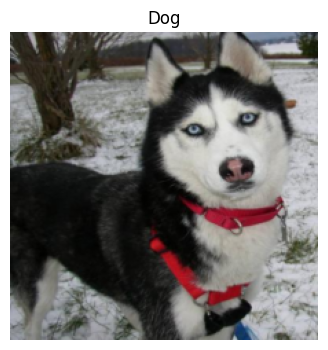

In [40]:
# Visualize a sample from the transfer learning dataset to verify the new transforms
def unnormalize(image): # unnormalize the image for visualization (since we normalized it for ResNet)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return image * std + mean

image, label = train_dataset_tl[0]
image_vis = unnormalize(image).permute(1, 2, 0).numpy()

plt.figure(figsize=(4,4))
plt.imshow(image_vis.clip(0, 1))
plt.title(full_dataset_train_tl.classes[label])
plt.axis("off")
plt.savefig("../figures/sample_image_tl.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# Load the pretrained ResNet18 model
weights = models.ResNet18_Weights.DEFAULT
model_tl = models.resnet18(weights=weights)

In [42]:
# Move to dvice
model_tl = model_tl.to(device)
print(model_tl)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
# Freeze the convolutional base (all layers except the final fully connected layer) to retain the pretrained features and only train the final layer for our specific task
for param in model_tl.parameters():
    param.requires_grad = False

In [44]:
# Check input size
print(model_tl.fc.in_features)

512


In [45]:
# Replace the final fully connected layer to match our number of classes (2 for cats vs dogs)
num_features = model_tl.fc.in_features

model_tl.fc = nn.Linear(num_features, 2)
model_tl = model_tl.to(device)

In [46]:
# Check which parameters are trainable (should only be the final layer: fc.weight and fc.bias)
for name, param in model_tl.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

fc.weight torch.Size([2, 512])
fc.bias torch.Size([2])


In [47]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

In [48]:
num_epochs = 10
train_losses_tl, train_accs_tl, val_losses_tl, val_accs_tl = training_loop(model_tl, train_loader_tl, val_loader_tl, criterion, optimizer_tl, num_epochs)

Epoch 1/10 | train loss: 0.1194, train acc: 0.9554 | val loss: 0.0672, val acc: 0.9744
Epoch 2/10 | train loss: 0.0796, train acc: 0.9685 | val loss: 0.0515, val acc: 0.9800
Epoch 3/10 | train loss: 0.0768, train acc: 0.9695 | val loss: 0.0506, val acc: 0.9792
Epoch 4/10 | train loss: 0.0696, train acc: 0.9724 | val loss: 0.0501, val acc: 0.9788
Epoch 5/10 | train loss: 0.0663, train acc: 0.9741 | val loss: 0.0511, val acc: 0.9808
Epoch 6/10 | train loss: 0.0715, train acc: 0.9708 | val loss: 0.0457, val acc: 0.9808
Epoch 7/10 | train loss: 0.0688, train acc: 0.9745 | val loss: 0.0467, val acc: 0.9820
Epoch 8/10 | train loss: 0.0728, train acc: 0.9723 | val loss: 0.0510, val acc: 0.9780
Epoch 9/10 | train loss: 0.0691, train acc: 0.9736 | val loss: 0.0475, val acc: 0.9800
Epoch 10/10 | train loss: 0.0703, train acc: 0.9733 | val loss: 0.0456, val acc: 0.9804


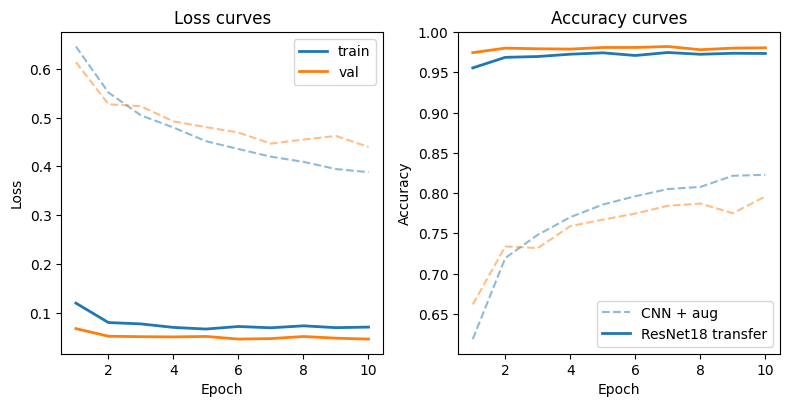

In [49]:
# Plot training and validation curves
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Loss : CNN + data augmentation
axes[0].plot(epochs, train_losses_aug, color='tab:blue', linestyle='dashed', alpha=0.5)
axes[0].plot(epochs, val_losses_aug, color='tab:orange', linestyle='dashed', alpha=0.5)
# Transfer learning
axes[0].plot(epochs, train_losses_tl, label="train", color='tab:blue', linestyle='solid', lw=2)
axes[0].plot(epochs, val_losses_tl, label="val", color='tab:orange', linestyle='solid', lw=2)

axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_aspect((axes[0].get_xlim()[1] - axes[0].get_xlim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0]))
axes[0].legend()

# Accuracy: CNN + data augmentation
axes[1].plot(epochs, train_accs_aug, label="CNN + aug", color='tab:blue', linestyle='dashed', alpha=0.5)
axes[1].plot(epochs, val_accs_aug, color='tab:orange', linestyle='dashed', alpha=0.5)
# Transfer learning
axes[1].plot(epochs, train_accs_tl, label="ResNet18 transfer", color='tab:blue', linestyle='solid', lw=2)
axes[1].plot(epochs, val_accs_tl, color='tab:orange', linestyle='solid', lw=2)

axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_aspect((axes[1].get_xlim()[1] - axes[1].get_xlim()[0]) / (axes[1].get_ylim()[1] - axes[1].get_ylim()[0])) 
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/transfer_learning_curves.png", dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# Evaluate the transfer learning model on the test set
model_tl.eval()

test_loss_tl = 0.0
test_correct_tl = 0
test_total_tl = 0

all_preds_tl = []
all_labels_tl = []
all_probs_tl = []
all_images_tl = []

with torch.no_grad():
    for images, labels in test_loader_tl:
        outputs = model_tl(images.to(device))
        loss = criterion(outputs, labels.to(device))

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        test_loss_tl += loss.item()
        test_correct_tl += (preds.cpu() == labels).sum().item()
        test_total_tl += labels.size(0)

        all_images_tl.append(images.cpu())
        all_probs_tl.append(probs.cpu())
        all_preds_tl.append(preds.cpu())
        all_labels_tl.append(labels.cpu())

test_loss_tl /= len(test_loader_tl)
test_acc_tl = test_correct_tl / test_total_tl

all_images_tl = torch.cat(all_images_tl)
all_probs_tl = torch.cat(all_probs_tl)
all_preds_tl = torch.cat(all_preds_tl)
all_labels_tl = torch.cat(all_labels_tl)

print(f"Transfer learning test loss: {test_loss_tl:.4f}")
print(f"Transfer learning test accuracy: {test_acc_tl:.4f}")

Transfer learning test loss: 0.0564
Transfer learning test accuracy: 0.9760


## Transfer Learning Results

Using a pretrained ResNet18 significantly improved performance compared to the custom CNN.

The model achieved ~98% accuracy on the test set, compared to ~80% for the custom CNN.

This large improvement is due to the pretrained model already learning rich visual features (edges, textures, object parts) from a large dataset (ImageNet). As a result, only a small classifier needed to be trained for the Cats vs Dogs task.

Additionally, the model converged much faster and showed better generalization, with no significant gap between training and validation accuracy.

This experiment highlights that:
- Training CNNs from scratch requires large datasets
- Transfer learning is highly effective for small to medium datasets
- Pretrained models can drastically reduce training time and improve performance